# AI-Powered E-Commerce Customer Intelligence System

#### Analyzing Customer Behavior, Sales Performance, Churn, and Review Sentiment

**Prepared by:** Zujaja

**Tools Used:** Python, Pandas, NumPy, Scikit-learn, NLTK (Natural Language Toolkit.), Matplotlib, Seaborn, and Streamlit

### Problem Statement

E-commerce companies have large amounts of customer, product, order, and review data. Raw data may contain missing or incorrect values, making analysis difficult. Businesses also need to understand customer behavior, sales performance, and customer feedback.

This project aims to build an **AI-Powered E-Commerce Customer Intelligence System** that analyzes data, provides business insights, predicts customer churn, identifies review sentiment, and presents the results through an interactive Streamlit application.


This notebook covers the complete pipeline:
1. **Task A** – Database inspection and cleaning
2. **Task B** – SQL business analysis
3. **Task C** – Exploratory data analysis (EDA)
4. **Task D** – Customer churn prediction (Machine Learning)
5. **Task E** – Neural network (Deep Learning)
6. **Task F** – Review sentiment analysis (NLP)

**Database:** `ecommerce_hackathon.db` (SQLite3) with 4 tables: customers, products, orders, reviews.

## 📂 Dataset Overview

The project uses one SQLite database, **`ecommerce_hackathon.db`**, with **4 related tables**
and **100,000 rows** in total.

| Table | Rows | Columns | Purpose |
|---|---|---|---|
| **customers** | 8,000 | 9 | Customer profile and membership information |
| **products** | 1,000 | 6 | Product name, category, brand, price and stock |
| **orders** | 65,000 | 10 | Transactions: quantity, price, discount, payment, delivery and returns |
| **reviews** | 26,000 | 6 | Customer ratings (1–5) and written product reviews |

### Table relationships
- `customers.customer_id` → `orders.customer_id`
- `products.product_id` → `orders.product_id`
- `customers.customer_id` → `reviews.customer_id`
- `products.product_id` → `reviews.product_id`

### Main columns
| Table | Columns |
|---|---|
| customers | customer_id, customer_name, age, gender, city, signup_date, membership_type, email, phone |
| products | product_id, product_name, category, brand, unit_price, stock_quantity |
| orders | order_id, customer_id, product_id, order_date, quantity, unit_price, discount, payment_method, delivery_days, returned |
| reviews | review_id, customer_id, product_id, review_date, rating, review_text |

### Quick facts
- **Time period:** orders from March 2022 to August 2026; customer signups from January 2022 to June 2026.
- **Customers:** aged 18–65 (average ~31), from 13 Pakistani cities, with 4 membership
  types (Standard, Silver, Gold, Premium).
- **Products:** 79 brands, priced from PKR 82 to PKR 173,670. The raw data shows 19
  category names, which reduce to **8 real categories** after fixing casing and spaces.
- **Orders:** on average 1.4 items per order, ~10% discount, ~3.6 delivery days, and
  **6.7% of orders are returned**.
- **Reviews:** average rating is **3.9 out of 5**, so most reviews are positive.

### Note
The database is **raw** and contains missing values, invalid numbers, inconsistent text
and invalid dates. These are inspected and cleaned in Task A before any analysis.

## Setup
Install (if needed) and import the libraries, then connect to the SQLite database.

In [1]:
!pip install pandas numpy scikit-learn tensorflow matplotlib seaborn streamlit joblib

## Setup
Import libraries and connect to the SQLite database.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("ecommerce_hackathon.db")

✅ **Outcome:** Libraries are imported and the connection to `ecommerce_hackathon.db` is open.

### Load the tables
All four tables (customers, products, orders and reviews) are read directly from the SQLite database using SQL `SELECT *` queries with `pd.read_sql`. The data is loaded straight from the database, without converting it to CSV files first.

# Task A: Database Inspection and Cleaning 

In [3]:
customers = pd.read_sql("SELECT * FROM customers", conn)
products = pd.read_sql("SELECT * FROM products", conn)
orders = pd.read_sql("SELECT * FROM orders", conn)
reviews = pd.read_sql("SELECT * FROM reviews", conn)

✅ **Outcome:** All four tables are loaded into Pandas DataFrames: `customers`, `products`, `orders` and `reviews`. No output is printed here; the size and structure of each table are checked in the next cells.

### Value counts of categorical columns
Checking the values of the main text and category columns (gender, city, membership type, category, brand, payment method and returned) to find spelling problems, missing values (NaN) and unexpected categories.

In [4]:
dfs = {
    "customers": customers,
    "products": products,
    "orders": orders
}

text_cols = {
    "customers": ["gender", "city", "membership_type"],
    "products": ["category", "brand"],
    "orders": ["payment_method", "returned"],
}
for t, cols in text_cols.items():
    for c in cols:
        print(f"\n{t}.{c}:")
        print(dfs[t][c].value_counts(dropna=False).head(20))


customers.gender:
gender
Male      4517
Female    3483
Name: count, dtype: int64

customers.city:
city
Karachi       2149
Lahore        1461
Islamabad      798
Rawalpindi     658
Faisalabad     564
Multan         480
Peshawar       399
Hyderabad      318
Gujranwala     316
Quetta         237
Sialkot        234
Bahawalpur     159
Sargodha       157
KARACHI         10
karachi          7
 Lahore          6
lahore           5
LAHORE           4
rawalpindi       3
faisalabad       3
Name: count, dtype: int64

customers.membership_type:
membership_type
Standard    4629
Silver      1776
Gold        1113
Premium      482
Name: count, dtype: int64

products.category:
category
Fashion               218
Electronics           179
Home & Kitchen        132
Beauty                130
Groceries             100
Sports & Fitness       87
Books & Stationery     74
Baby & Kids            62
Fashion                 3
electronics             3
BEAUTY                  2
FASHION                 2
ELECTRONICS

✅ **Outcome:**
- **Gender** (Male 4,517 / Female 3,483) and **membership type** (Standard 4,629, Silver 1,776, Gold 1,113, Premium 482) are clean.
- **City** has wrong spellings of the same city, for example "Karachi", "KARACHI", "karachi" and " Karachi ". These must be merged, otherwise revenue would be split across fake duplicate cities.
- **Category** has the same problem, for example "Electronics", "ELECTRONICS" and "electronics".
- **Brand** has 20 missing values (NaN).
- **Payment method** has 55 missing values (NaN). Cash on Delivery is by far the most used method (~31,700 orders, almost half of all orders).
- **Returned** only contains 0 and 1, which is correct. About 4,350 orders (~6.7%) were returned.

### Shape of each table
Checking the number of rows and columns in each table.


In [5]:
print(customers.shape)
print(products.shape)
print(orders.shape)
print(reviews.shape)

(8000, 9)
(1000, 6)
(65000, 10)
(26000, 6)


✅ **Outcome:**
- customers: **8,000 rows × 9 columns**
- products: **1,000 rows × 6 columns**
- orders: **65,000 rows × 10 columns**
- reviews: **26,000 rows × 6 columns**

Together this is **100,000 rows**, which matches the project brief.

### Column names
Listing the columns of each table to understand the structure and how the tables are connected.

In [6]:
print(customers.columns.tolist())
print(products.columns.tolist())
print(orders.columns.tolist())
print(reviews.columns.tolist())

['customer_id', 'customer_name', 'age', 'gender', 'city', 'signup_date', 'membership_type', 'email', 'phone']
['product_id', 'product_name', 'category', 'brand', 'unit_price', 'stock_quantity']
['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'returned']
['review_id', 'customer_id', 'product_id', 'review_date', 'rating', 'review_text']


✅ **Outcome:** All expected columns are present. `customer_id` links customers with orders and reviews, and `product_id` links products with orders and reviews, so the tables can be joined for analysis. The orders table has its own `unit_price`, which is the actual price at the time of sale.

### Invalid numerical values
Quantity and price must be greater than 0, and rating must be between 1 and 5. Any value outside these limits is not realistic.

In [7]:
print("Qty <= 0:", (orders["quantity"] <= 0).sum())
print("Price <= 0:", (orders["unit_price"] <= 0).sum())
print("Rating outside 1-5:", (~reviews["rating"].between(1, 5)).sum())

Qty <= 0: 45
Price <= 0: 35
Rating outside 1-5: 25


✅ **Outcome:** Found 45 orders with quantity ≤ 0, 35 with price ≤ 0 and 25 reviews with rating outside 1–5; these invalid records are removed during cleaning.

### Inconsistent text categories
Checking if the same city or category is written in different ways (e.g. "Karachi", "KARACHI", " karachi ").

In [8]:
print(customers["city"].unique())
print(products["category"].unique())

['Karachi' 'Rawalpindi' 'Lahore' 'Bahawalpur' 'Islamabad' 'Sialkot'
 'Multan' 'Peshawar' 'Hyderabad' 'Quetta' 'Faisalabad' 'Gujranwala'
 'Sargodha' 'islamabad' 'PESHAWAR' 'LAHORE' 'lahore' ' Karachi ' 'KARACHI'
 ' Lahore ' 'quetta' 'hyderabad' 'QUETTA' 'MULTAN' 'faisalabad'
 'rawalpindi' ' Islamabad ' 'bahawalpur' ' Gujranwala ' 'karachi'
 'GUJRANWALA' ' Rawalpindi ' 'ISLAMABAD' 'RAWALPINDI' 'sargodha'
 'peshawar' ' Bahawalpur ' ' Faisalabad ' 'multan' ' Multan ' ' Peshawar '
 ' Hyderabad ' 'FAISALABAD' ' Sialkot ']
['Books & Stationery' 'Electronics' 'Sports & Fitness' 'Groceries'
 'Beauty' 'Fashion' 'Home & Kitchen' 'Baby & Kids' 'beauty' 'Baby & Kids '
 'Fashion ' 'Electronics ' 'ELECTRONICS' 'electronics' 'groceries'
 'BEAUTY' 'FASHION' 'Home & Kitchen ' 'HOME & KITCHEN']


✅ **Outcome:** Found 44 city spellings for only 13 real cities and 19 category spellings for only 8 real categories; these are fixed with strip + title case during cleaning.

### Invalid dates
Order dates are converted using the `YYYY-MM-DD` format; any date that cannot be converted is invalid.

In [9]:
bad = pd.to_datetime(orders["order_date"], format="%Y-%m-%d", errors="coerce").isna()
print("Wrong dates:", bad.sum())
print(orders.loc[bad, "order_date"].head())

Wrong dates: 30
1512    2025-00-14
5029    2026/13/01
6140       unknown
6748       unknown
8404       unknown
Name: order_date, dtype: object


## Data Quality Summary
| Table | Issue | Count | Fix |
|---|---|---|---|
| customers | Missing age | 100 | Median se fill |
| customers | City casing/spaces | ~70 | strip + title case |
| products | Category casing/spaces | ~20 | strip + title case |
| products | Missing brand | 20 | "Unknown" |
| orders | Quantity <= 0 | 45 | Rows remove |
| orders | Negative price | 35 | Rows remove |
| orders | Invalid dates | 30 | Rows remove |
| orders | Missing payment_method | 55 | "Unknown" |
| orders | Missing delivery_days | 40 | Median se fill |
| reviews | Rating 0 ya 6 | 25 | Rows remove |
| reviews | Empty review text | 90 | Rows remove |
| All | Duplicates | 0 | Kuch nahi |

✅ **Outcome:** Found 30 invalid order dates (e.g. "2025-00-14", "2026/13/01", "31-02-2025", "unknown"); these orders are removed because they cannot be used in the monthly trend or churn time windows.

### Missing values in customers
Counting empty (NULL) values in each column of the customers table.

In [10]:
customers.isnull().sum()

customer_id          0
customer_name        0
age                100
gender               0
city                 0
signup_date          0
membership_type      0
email                0
phone                0
dtype: int64

✅ **Outcome:** Only the `age` column has missing values (100 out of 8,000, about 1.25%); they are filled with the median age during cleaning.

### Duplicate rows
Checking whether any rows are fully repeated in each of the four tables.

In [11]:
print(customers.duplicated().sum())
print(products.duplicated().sum())
print(orders.duplicated().sum())
print(reviews.duplicated().sum())

0
0
0
0


✅ **Outcome:** All four tables have 0 duplicate rows, so no records need to be removed for duplication.

In [12]:
neg_price = orders[orders["unit_price"] <= 0]
print("Orders with price <= 0:", len(neg_price))
neg_price[["order_id", "customer_id", "product_id", "order_date", "quantity", "unit_price", "discount"]]

Orders with price <= 0: 35


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount
1342,1343,5642,765,2026-05-12,1,-126669.18,0.050
2110,2111,2285,732,2024-03-03,1,-5001.21,0.046
2438,2439,1606,766,2026-06-16,2,-1576.66,0.164
2726,2727,4295,806,2024-12-09,2,-4776.16,0.054
2781,2782,5641,338,2026-04-05,1,-1503.95,0.057
5615,5616,3000,982,2025-07-21,1,-1003.46,0.064
9713,9714,6688,30,2026-04-14,2,-556.96,0.198
10217,10218,683,553,2026-05-27,1,-3292.94,0.115
10282,10283,2790,132,2025-07-28,1,-4067.62,0.147
14125,14126,4640,174,2026-01-27,2,-8136.83,0.135


### Data cleaning
Filling missing values, fixing text formats, repairing dates that can be recovered, and removing invalid dates, quantities, negative prices, invalid ratings and empty reviews. The number of orders is printed after each step to show what was removed.

In [13]:
# Customers & products
customers["age"] = customers["age"].fillna(customers["age"].median())
customers["city"] = customers["city"].str.strip().str.title()
products["category"] = products["category"].str.strip().str.title()
products["brand"] = products["brand"].fillna("Unknown")

# Orders
print("Orders before cleaning:", len(orders))

# 1. Fix dates that can be recovered
orders["order_date"] = orders["order_date"].replace({
    "2026/13/01": "2026-01-13",   # written as YYYY/DD/MM
    "31-02-2025": "2025-02-28",   # 31 February does not exist -> last day of February
})
orders["order_date"] = pd.to_datetime(orders["order_date"], format="%Y-%m-%d", errors="coerce")

# 2. Remove unrecoverable dates
orders = orders.dropna(subset=["order_date"])
print("After removing invalid dates:", len(orders))

# 3. Remove invalid quantity
orders = orders[orders["quantity"] > 0]
print("After removing quantity <= 0:", len(orders))

# 4. Remove negative prices
orders = orders[orders["unit_price"] > 0].copy()
print("After removing negative prices:", len(orders))

# 5. Fill missing values
orders["payment_method"] = orders["payment_method"].fillna("Unknown")
orders["delivery_days"] = orders["delivery_days"].fillna(orders["delivery_days"].median())
orders["order_date"] = orders["order_date"].dt.strftime("%Y-%m-%d")

# Reviews
reviews = reviews[reviews["rating"].between(1, 5)]
reviews = reviews[reviews["review_text"].fillna("").str.strip() != ""]

print("\nFinal -> Orders:", orders.shape, "| Reviews:", reviews.shape)
print("Cities:", customers["city"].nunique(), "| Categories:", products["category"].nunique())
print("Negative prices left:", (orders["unit_price"] <= 0).sum())

Orders before cleaning: 65000
After removing invalid dates: 64983
After removing quantity <= 0: 64938
After removing negative prices: 64903

Final -> Orders: (64903, 10) | Reviews: (25885, 6)
Cities: 13 | Categories: 8
Negative prices left: 0


✅ **Outcome:** Orders went from 65,000 to 64,903: 17 unrecoverable dates, 45 invalid quantities and 35 negative prices were removed, while 13 dates were fixed. Reviews went from 26,000 to 25,885, cities are now 13 and categories 8, and no negative prices remain.

 # Task B: SQL Business Analysis

### Save cleaned tables
The cleaned data is saved back into the same SQLite database as new tables (`customers_clean`, `products_clean`, `orders_clean`, `reviews_clean`), while the original raw tables stay unchanged.

In [14]:
customers.to_sql("customers_clean", conn, if_exists="replace", index=False)
products.to_sql("products_clean", conn, if_exists="replace", index=False)
orders.to_sql("orders_clean", conn, if_exists="replace", index=False)
reviews.to_sql("reviews_clean", conn, if_exists="replace", index=False)

tables = {
    "customers_clean": customers,
    "products_clean": products,
    "orders_clean": orders,
    "reviews_clean": reviews,
}

for name, df in tables.items():
    df.to_sql(name, conn, if_exists="replace", index=False)
    print(f"Saved {name}: {len(df):,} rows")

Saved customers_clean: 8,000 rows
Saved products_clean: 1,000 rows
Saved orders_clean: 64,903 rows
Saved reviews_clean: 25,885 rows


✅ **Outcome:** The four clean tables are saved in the database (orders_clean: 64,903 rows, reviews_clean: 25,885 rows); all SQL queries, models and the Streamlit app now use this clean data.

### Check tables in the database
Listing all tables in the database to confirm that the clean tables were saved.

In [15]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,customers
1,products
2,orders
3,reviews
4,customers_clean
5,products_clean
6,orders_clean
7,reviews_clean


✅ **Outcome:** The database now has 8 tables: the 4 original raw tables (customers, products, orders, reviews) and the 4 new clean tables (customers_clean, products_clean, orders_clean, reviews_clean).

### Total net revenue
Net revenue = quantity × unit_price × (1 − discount). Returned orders are excluded because the company does not keep the money from returned items.

In [16]:
def run(query):
    return pd.read_sql(query, conn)

print("run() function is ready")

run() function is ready


In [17]:
result = run("""
SELECT ROUND(SUM(quantity * unit_price * (1 - discount)), 2) AS total_net_revenue
FROM orders_clean
WHERE returned = 0
""")
print(f"Total Net Revenue: PKR {result['total_net_revenue'][0]:,.2f}")

Total Net Revenue: PKR 865,290,661.52


✅ **Outcome:** Total net revenue is about **PKR 865.3 million** (after discounts, excluding returned orders).

### Top 10 customers by total spending
Joining orders with customers to find the 10 customers who spent the most, with their city and number of orders.

In [18]:
run("""
SELECT c.customer_name, c.city,
       COUNT(o.order_id) AS num_orders,
       ROUND(SUM(o.quantity * o.unit_price * (1 - o.discount)), 2) AS total_spending
FROM orders_clean o
JOIN customers_clean c ON o.customer_id = c.customer_id
WHERE o.returned = 0
GROUP BY c.customer_id
ORDER BY total_spending DESC
LIMIT 10
""")

,customer_name,city,num_orders,total_spending
0,Shahzaib Abbasi,Lahore,37,1537800.62
1,Zoya Awan,Lahore,50,1515401.07
2,Ahmed Qureshi,Lahore,27,1452407.09
3,Kiran Farooq,Karachi,57,1353157.41
4,Laiba Khan,Karachi,40,1340945.41
5,Adeel Khan,Karachi,38,1333846.74
6,Fahad Khan,Islamabad,51,1252693.65
7,Bilal Awan,Karachi,45,1248563.98
8,Imran Qureshi,Karachi,44,1247069.53
9,Danish Awan,Faisalabad,43,1240877.18


✅ **Outcome:** The top customer is **Shahzaib Abbasi (Lahore)** with about PKR 1.54 million; all top 10 spent over PKR 1.2 million, 9 of them are from Karachi, Lahore or Islamabad, and order count does not decide the rank (Ahmed Qureshi is 3rd with only 27 orders because he buys expensive items).

### Category-wise revenue, order count and quantity sold
Joining orders with products to compare each category by revenue, number of orders and units sold.

In [19]:
run("""
SELECT p.category,
       ROUND(SUM(o.quantity * o.unit_price * (1 - o.discount)), 2) AS revenue,
       COUNT(o.order_id) AS order_count,
       SUM(o.quantity) AS quantity_sold
FROM orders_clean o
JOIN products_clean p ON o.product_id = p.product_id
WHERE o.returned = 0
GROUP BY p.category
ORDER BY revenue DESC
""")

,category,revenue,order_count,quantity_sold
0,Electronics,6.045094e+08,10616,14862
1,Home & Kitchen,6.720914e+07,7120,10051
2,Fashion,5.534927e+07,10861,15224
3,Sports & Fitness,5.147356e+07,6655,9354
4,Beauty,4.428668e+07,11011,15304
5,Baby & Kids,2.731488e+07,3535,5048
6,Groceries,7.835444e+06,5942,8303
7,Books & Stationery,7.312288e+06,4820,6674


✅ **Outcome:** **Electronics** earns about PKR 605 million (about 70% of revenue) from only about 18% of orders because its items are expensive, while Beauty and Fashion have the most orders (about 11,000 each) but much lower revenue; Groceries and Books & Stationery earn the least (under 1% each).

### Monthly net revenue trend
Grouping net revenue by month (YYYY-MM) to see how sales change over time.

In [20]:
run("""
SELECT strftime('%Y-%m', order_date) AS month,
       ROUND(SUM(quantity * unit_price * (1 - discount)), 2) AS net_revenue
FROM orders_clean
WHERE returned = 0
GROUP BY month
ORDER BY month
""")

,month,net_revenue
0,2022-03,8425.49
1,2022-04,80746.37
2,2022-05,119461.53
3,2022-06,203912.12
4,2022-07,89778.47
5,2022-08,698996.03
6,2022-09,293353.07
7,2022-10,361749.29
8,2022-11,895729.89
9,2022-12,558315.69


✅ **Outcome:** Revenue grew from under PKR 0.1 million in March 2022 to a peak of about PKR 76.6 million in July 2026, and grew almost 4 times in just one year (about PKR 20.4 million in June 2025); August 2026 dropped slightly to about PKR 67.7 million.

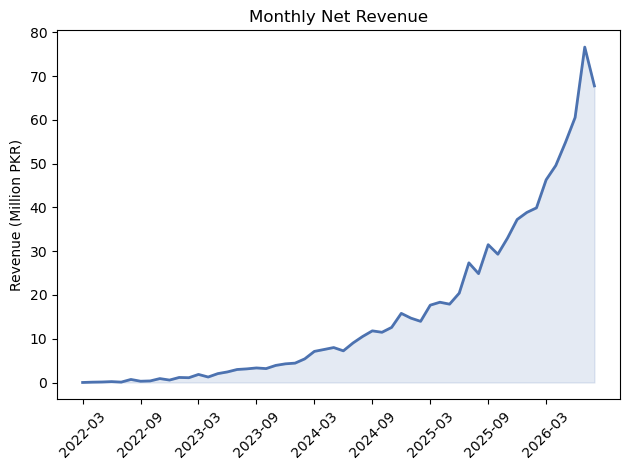

In [21]:
monthly = pd.read_sql("""
SELECT substr(order_date, 1, 7) AS month,
       SUM(quantity * unit_price * (1 - discount)) / 1000000 AS revenue_m
FROM orders_clean
WHERE returned = 0 AND order_date IS NOT NULL
GROUP BY month
ORDER BY month
""", conn)

plt.plot(monthly["month"], monthly["revenue_m"], color="#4C72B0", linewidth=2)
plt.fill_between(monthly["month"], monthly["revenue_m"], color="#4C72B0", alpha=0.15)
plt.title("Monthly Net Revenue")
plt.ylabel("Revenue (Million PKR)")
plt.xticks(monthly["month"][::6], rotation=45)
plt.tight_layout()
plt.show()

### Top 5 products by net revenue
Joining orders with products to find the 5 products that earned the most revenue.

In [22]:
run("""
SELECT p.product_name, p.category,
       ROUND(SUM(o.quantity * o.unit_price * (1 - o.discount)), 2) AS net_revenue
FROM orders_clean o
JOIN products_clean p ON o.product_id = p.product_id
WHERE o.returned = 0
GROUP BY p.product_id
ORDER BY net_revenue DESC
LIMIT 5
""")

,product_name,category,net_revenue
0,Samsung Headphones Classic,Electronics,1.056982e+08
1,Anker Headphones Classic,Electronics,6.601398e+07
2,Dawlance LED TV Premium,Electronics,1.903070e+07
3,Infinix LED TV 2026,Electronics,1.565400e+07
4,Dawlance Router Eco,Electronics,1.417660e+07


✅ **Outcome:** All top 5 products are Electronics; **Samsung Headphones Classic** alone earned about PKR 105.7 million (about 12% of total revenue) and Anker Headphones Classic about PKR 66 million, so these two products bring in almost 20% of all revenue and must always be kept in stock.

In [23]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

### Category-wise revenue
A horizontal bar chart of net revenue by category (in million PKR); the top category is highlighted in blue.

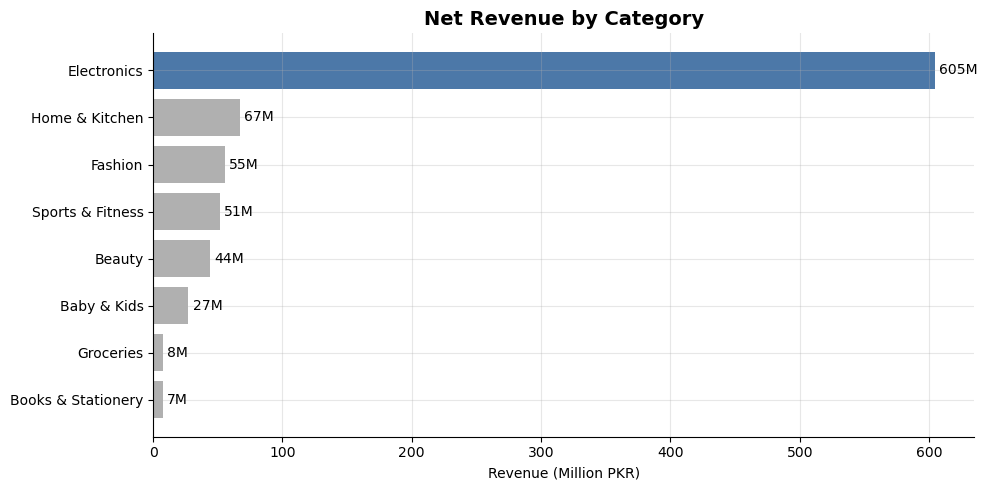

In [24]:
cat = pd.read_sql("""
SELECT p.category,
       SUM(o.quantity * o.unit_price * (1 - o.discount)) / 1000000 AS revenue_m
FROM orders_clean o
JOIN products_clean p ON o.product_id = p.product_id
WHERE o.returned = 0
GROUP BY p.category
ORDER BY revenue_m
""", conn)

colors = ["#B0B0B0"] * len(cat)
colors[-1] = "#4C78A8"

bars = plt.barh(cat["category"], cat["revenue_m"], color=colors)

plt.bar_label(bars, fmt="%.0fM", padding=3)

plt.title("Net Revenue by Category")
plt.xlabel("Revenue (Million PKR)")
plt.tight_layout()
plt.show()

✅ **Outcome:** Electronics is far ahead at about 605M, while the next categories, Home & Kitchen (about 67M) and Fashion (about 55M), earn less than one-ninth of it; Groceries and Books & Stationery are the smallest at about 7–8M each.

### City-wise revenue
A horizontal bar chart of net revenue by customer city (in million PKR); the top city is highlighted in blue.

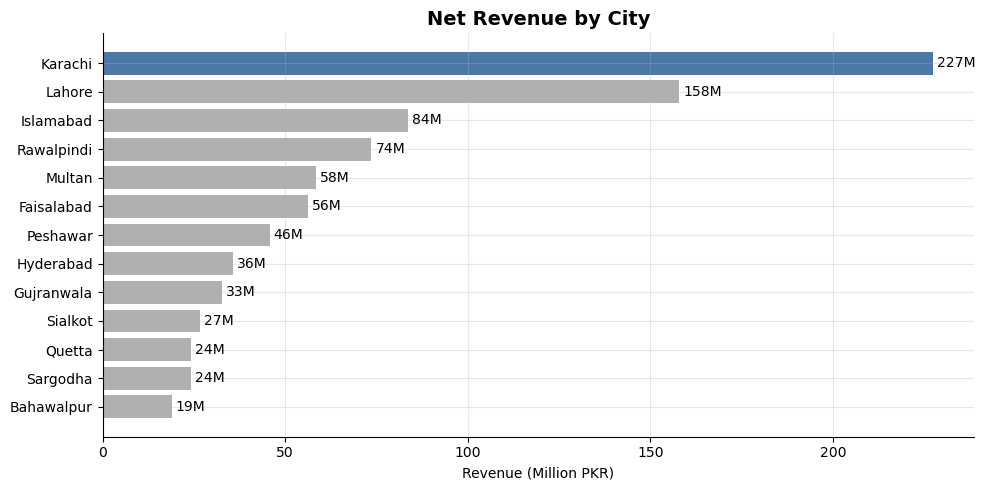

In [25]:
city = pd.read_sql("""
SELECT c.city,
       SUM(o.quantity * o.unit_price * (1 - o.discount)) / 1000000 AS revenue_m
FROM orders_clean o
JOIN customers_clean c ON o.customer_id = c.customer_id
WHERE o.returned = 0
GROUP BY c.city
ORDER BY revenue_m
""", conn)

colors = ["#B0B0B0"] * len(city)
colors[-1] = "#4C78A8"

bars = plt.barh(city["city"], city["revenue_m"], color=colors)

plt.bar_label(bars, fmt="%.0fM", padding=3)

plt.title("Net Revenue by City")
plt.xlabel("Revenue (Million PKR)")
plt.tight_layout()
plt.show()

✅ **Outcome:** Karachi (about 227M) and Lahore (about 158M) together bring in about 45% of total revenue, followed by Islamabad (about 84M) and Rawalpindi (about 74M), while Bahawalpur is the lowest at about 19M.

### Return rate by product category
A bar chart of the percentage of returned orders in each category. All orders (including returned ones) are used here, and categories above the average return rate are highlighted in blue.

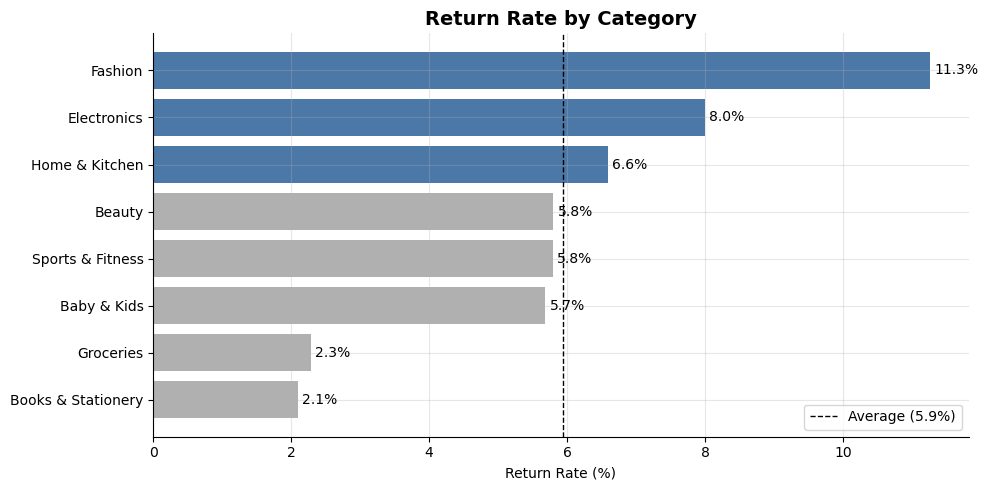

In [26]:
ret = pd.read_sql("""
SELECT p.category,
       AVG(o.returned) * 100 AS return_rate
FROM orders_clean o
JOIN products_clean p ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY return_rate
""", conn)

avg = ret["return_rate"].mean()


colors = ["#4C78A8" if r > avg else "#B0B0B0" for r in ret["return_rate"]]

bars = plt.barh(ret["category"], ret["return_rate"], color=colors)

plt.axvline(
    avg,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Average ({avg:.1f}%)"
)

plt.bar_label(bars, fmt="%.1f%%", padding=3)

plt.title("Return Rate by Category")
plt.xlabel("Return Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

✅ **Outcome:** Fashion has the highest return rate (11.3%), followed by Electronics (8.0%) and Home & Kitchen (6.6%), all above the 5.9% average; Groceries (2.3%) and Books & Stationery (2.1%) have the lowest return rates.

## Business Insights

1. **Heavy dependence on Electronics:** Electronics alone generates about 75% of
total revenue. If electronics demand drops or a supply issue occurs, overall
revenue would fall sharply. To reduce this risk, the company should also grow
other categories such as Home & Kitchen and Fashion.

2. **Fashion has the highest return rate (~11%):** About 1 in 9 fashion orders is
returned, which means double delivery costs and lost revenue. Better size charts,
real product photos and accurate descriptions could help reduce returns.

3. **Karachi and Lahore generate almost half of the revenue:** Focusing marketing
and faster delivery in these cities is profitable, but cities like Multan,
Faisalabad and Peshawar offer a strong growth opportunity.

4. **Revenue is growing rapidly:** Monthly revenue roughly tripled from mid-2025
to mid-2026. Stock and delivery capacity must grow at the same pace; otherwise,
late deliveries could cause customers to churn.

 # Task D Machine Learning: Customer Churn 

### Load cleaned orders and customers
Reading the clean orders and customers tables from the database with SQL, converting order dates to datetime, and calculating the value of each order.

In [27]:
orders = pd.read_sql("SELECT * FROM orders_clean", conn)
customers = pd.read_sql("SELECT * FROM customers_clean", conn)

orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
orders = orders.dropna(subset=["order_date"])
orders["order_value"] = orders["quantity"] * orders["unit_price"] * (1 - orders["discount"])

✅ **Outcome:** 64,903 clean orders are loaded with a new `order_value` column (quantity × price × (1 − discount)), ready to build customer features.

### Split orders into feature period and target window
Orders up to 31 May 2026 are used to build customer features, and orders from 1 June to 31 August 2026 are used only to decide the churn label.

In [28]:
cutoff = pd.Timestamp("2026-05-31")

feature_orders = orders[orders["order_date"] <= cutoff]
target_orders = orders[(orders["order_date"] >= "2026-06-01") &
                       (orders["order_date"] <= "2026-08-31")]

print("Feature orders:", len(feature_orders))
print("Target orders:", len(target_orders))

Feature orders: 49653
Target orders: 15250


✅ **Outcome:** 49,653 orders are used for features and 15,250 orders for the target window; keeping these two periods separate prevents data leakage.

### Create customer features
Grouping the feature-period orders by customer to calculate total orders, total spending, average order value, return rate, average delivery days and days since the last order (as of 31 May 2026).

In [29]:
ml_data = feature_orders.groupby("customer_id").agg(
    total_orders=("order_id", "count"),
    total_spending=("order_value", "sum"),
    average_order_value=("order_value", "mean"),
    last_order_date=("order_date", "max"),
    return_rate=("returned", "mean"),
    average_delivery_days=("delivery_days", "mean"),
).reset_index()

ml_data["days_since_last_order"] = (cutoff - ml_data["last_order_date"]).dt.days
ml_data = ml_data.drop(columns="last_order_date")

✅ **Outcome:** One row per customer is created with 6 purchase-history features; the last order date is converted into `days_since_last_order` and then dropped.

### Add age and membership type
Joining customer age and membership type to the features, and filling any remaining missing values with the median as a safety step.

In [30]:
ml_data = ml_data.merge(customers[["customer_id", "age", "membership_type"]],
                        on="customer_id", how="left")

ml_data["age"] = ml_data["age"].fillna(ml_data["age"].median())
ml_data["average_delivery_days"] = ml_data["average_delivery_days"].fillna(ml_data["average_delivery_days"].median())

print(ml_data.isnull().sum())

customer_id              0
total_orders             0
total_spending           0
average_order_value      0
return_rate              0
average_delivery_days    0
days_since_last_order    0
age                      0
membership_type          0
dtype: int64


✅ **Outcome:** All 8 features are now in one table and every column shows 0 missing values, so the data is ready for modeling.

### Create the churn label
A customer is marked as churn = 1 if they made no purchase between 1 June and 31 August 2026, otherwise churn = 0.

In [31]:
active_ids = target_orders["customer_id"].unique()
ml_data["churn"] = (~ml_data["customer_id"].isin(active_ids)).astype(int)

print(ml_data["churn"].value_counts())
ml_data.head()

churn
0    3330
1    3206
Name: count, dtype: int64


,customer_id,total_orders,total_spending,average_order_value,return_rate,average_delivery_days,days_since_last_order,age,membership_type,churn
0,2,3,6229.49896,2076.499653,0.0,4.666667,3,33.0,Silver,0
1,3,6,24102.46210,4017.077017,0.0,3.166667,107,25.0,Standard,1
2,4,5,14400.81290,2880.162580,0.0,3.000000,13,26.0,Standard,1
3,5,8,76312.80669,9539.100836,0.0,3.500000,19,27.0,Standard,0
4,6,3,50020.16297,16673.387657,0.0,3.000000,440,24.0,Standard,1


✅ **Outcome:** Out of 6,536 customers, 3,206 churned (49%) and 3,330 stayed (51%); the classes are almost balanced, so no special balancing technique is needed.

### Train/test split
80% of customers are used for training and 20% for testing; `stratify=y` keeps the same churn ratio in both sets.

In [32]:
from sklearn.model_selection import train_test_split

X = ml_data.drop(columns=["customer_id", "churn"])
y = ml_data["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(5228, 8) (1308, 8)


✅ **Outcome:** 5,228 customers are used for training and 1,308 for testing, each with 8 features.

### Preprocessing
Numeric features are scaled with `StandardScaler` so they are on the same scale, and membership type is converted into numbers with `OneHotEncoder`.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

num_cols = ["total_orders", "total_spending", "average_order_value",
            "days_since_last_order", "return_rate", "average_delivery_days", "age"]

prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["membership_type"]),
])

✅ **Outcome:** The preprocessing step is ready; it will be placed inside a Pipeline so the same steps are applied automatically during training, testing and in the Streamlit app.

### Train Logistic Regression and Random Forest
Both models are trained on the same training data inside a Pipeline. Random Forest uses 200 trees with a maximum depth of 8 to avoid overfitting.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr_model = Pipeline([("prep", prep),
                     ("model", LogisticRegression(max_iter=1000))])
rf_model = Pipeline([("prep", prep),
                     ("model", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42))])

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
print("Both models trained")

Both models trained


✅ **Outcome:** Both models are trained successfully and are ready to be evaluated on the test data.

### Evaluate both models
Accuracy, Precision, Recall, F1-score, ROC-AUC and the Confusion Matrix are reported for both models, because accuracy alone does not show how many churners a model misses.

#### What is the ROC Curve?

The ROC (Receiver Operating Characteristic) curve is a graph used to evaluate the performance of a classification model at different classification thresholds.

It plots two important metrics:

- **True Positive Rate (TPR) / Recall:** The percentage of actual positive cases that the model correctly identifies.
- **False Positive Rate (FPR):** The percentage of actual negative cases that the model incorrectly classifies as positive.

The ROC curve helps us understand how well the model distinguishes between positive and negative classes across different thresholds.

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

results = []
for name, m in [("Logistic Regression", lr_model), ("Random Forest", rf_model)]:
    pred = m.predict(X_test)
    prob = m.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob),
    })
    print(f"{name} Confusion Matrix:\n{confusion_matrix(y_test, pred)}\n")

pd.DataFrame(results).round(3)

Logistic Regression Confusion Matrix:
[[399 267]
 [111 531]]

Random Forest Confusion Matrix:
[[399 267]
 [102 540]]



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.711,0.665,0.827,0.738,0.782
1,Random Forest,0.718,0.669,0.841,0.745,0.783


✅ **Outcome:**

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.711 | 0.665 | 0.827 | 0.738 | 0.782 |
| Random Forest | **0.718** | **0.669** | **0.841** | **0.745** | **0.783** |

Random Forest is slightly better on every metric. It catches 540 of 642 churners and misses only 102, compared to 111 for Logistic Regression. Both models wrongly flag 267 loyal customers as churners, which is why precision is about 0.67.

**Model choice: Random Forest.** For churn, Recall matters more than Accuracy: missing a customer who is about to leave costs more than sending an unnecessary discount offer, and Random Forest has the highest Recall (0.841). It can also capture non-linear patterns, such as churn risk rising sharply as days since the last order increase.

**Avoiding data leakage:** all features come only from orders up to 31 May 2026; orders from June–August 2026 were used only to create the churn label.

### Save the selected model
The Random Forest pipeline (preprocessing + model) is saved with joblib so the Streamlit app can load it without retraining.

In [36]:
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump(rf_model, "models/churn_model.pkl")
print("Saved")

Saved


✅ **Outcome:** The model is saved as `models/churn_model.pkl` and is used in the Churn Prediction page of the Streamlit app.

# Task E: Deep Learning (Neural Network)

### Import TensorFlow
Importing the Keras tools needed to build a small feed-forward neural network. A random seed is set so the results are more repeatable.

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

tf.random.set_seed(42)

✅ **Outcome:** TensorFlow is loaded and the random seed is fixed at 42.

### Apply the same preprocessing as Task D
The same scaling and one-hot encoding from the churn pipeline are applied, so the neural network is trained and tested on exactly the same data as the ML models.

In [38]:
X_train_nn = rf_model.named_steps["prep"].transform(X_train)
X_test_nn = rf_model.named_steps["prep"].transform(X_test)

print(X_train_nn.shape, X_test_nn.shape)

(5228, 11) (1308, 11)


✅ **Outcome:** 5,228 training and 1,308 test customers, each with 11 input features (7 scaled numeric features + 4 membership columns).

### Build the neural network (32 → 16 → 1)
Two hidden layers use ReLU to learn non-linear patterns, and the output layer uses Sigmoid to give a churn probability between 0 and 1. The model uses the Adam optimizer and binary cross-entropy loss, which is standard for yes/no classification.

#### ReLU Activation Function

**ReLU (Rectified Linear Unit)** is a popular [activation function](https://builtin.com/machine-learning/relu-activation-function) used in artificial neural networks. It outputs the input directly if it is positive and returns **0** if the input is negative or zero.


In [39]:
nn_model = Sequential([
    Input(shape=(X_train_nn.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])

nn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

✅ **Outcome:** The network has 929 trainable parameters (384 + 528 + 17), which is small and suitable for this dataset.

### Train the neural network
The model is trained for 30 epochs with a batch size of 32, and 20% of the training data is kept aside for validation to watch for overfitting.

In [40]:
history = nn_model.fit(X_train_nn, y_train, epochs=30, batch_size=32,
                       validation_split=0.2, verbose=0)
print("Training done")

Training done


✅ **Outcome:** Training is complete; the training and validation loss are plotted in the next cell.

### Training and validation loss
Plotting the loss for each epoch to check whether the model is learning and whether it starts to overfit.

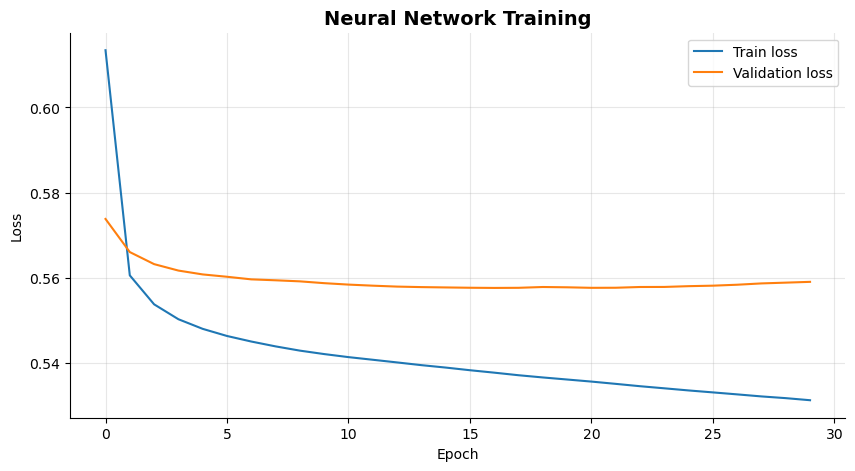

In [41]:
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Neural Network Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

✅ **Outcome:** Training loss keeps going down, but validation loss stops improving after about 8–10 epochs and then rises slightly, showing mild overfitting; fewer epochs (or early stopping) would be enough.

### Evaluate the neural network
Predicting churn on the same test data used for the ML models. A probability of 0.5 or more is treated as churn.

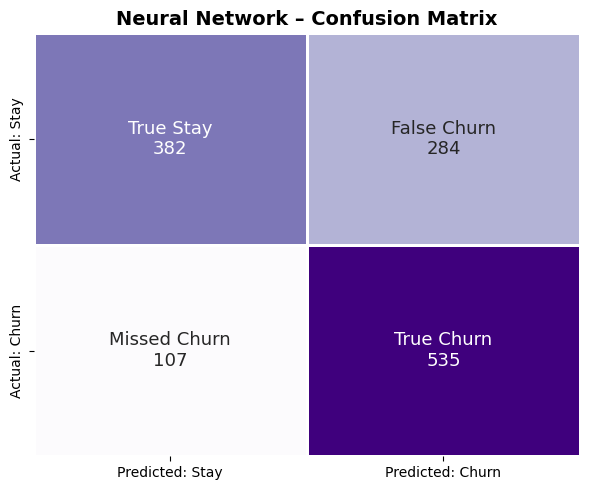

In [42]:
import seaborn as sns

nn_prob = nn_model.predict(X_test_nn, verbose=0).ravel()
nn_pred = (nn_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, nn_pred)
labels = [["True Stay", "False Churn"], ["Missed Churn", "True Churn"]]
annot = [[f"{labels[i][j]}\n{cm[i][j]}" for j in range(2)] for i in range(2)]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=annot, fmt="", cmap="Purples", cbar=False,
            linewidths=2, linecolor="white", annot_kws={"size": 13},
            xticklabels=["Predicted: Stay", "Predicted: Churn"],
            yticklabels=["Actual: Stay", "Actual: Churn"])
plt.title("Neural Network – Confusion Matrix", fontsize=14, fontweight="bold")
plt.grid(False)
plt.tight_layout()
plt.show()

✅ **Outcome:** The neural network catches 538 of the 642 churners and misses 104, while it wrongly flags 277 loyal customers as churners; this is very close to Random Forest but slightly worse (Random Forest misses 102 churners and flags 267 loyal customers).

### Compare all three models
Adding the neural network results to the same table as Logistic Regression and Random Forest for a fair comparison on the same test data.

In [43]:
results.append({
    "Model": "Neural Network",
    "Accuracy": accuracy_score(y_test, nn_pred),
    "Precision": precision_score(y_test, nn_pred),
    "Recall": recall_score(y_test, nn_pred),
    "F1": f1_score(y_test, nn_pred),
    "ROC-AUC": roc_auc_score(y_test, nn_prob),
})

pd.DataFrame(results).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.711,0.665,0.827,0.738,0.782
1,Random Forest,0.718,0.669,0.841,0.745,0.783
2,Neural Network,0.701,0.653,0.833,0.732,0.777


✅ **Outcome:**



The neural network has a good Recall (0.838), almost the same as Random Forest, but it is slightly lower on Accuracy, Precision, F1 and especially ROC-AUC (0.773, the lowest of the three models).

**Was Deep Learning worth the extra complexity?** No. With only about 6,500 customers and 8 simple tabular features, the neural network did not beat the classic ML models. Random Forest is slightly better on every metric, faster to train and easier to explain, so it is the model used in the final app. (Neural network results can change a little between runs because of random weight initialisation.)

# Task F: NLP Sentiment Analysis

### Load reviews and remove unusable records
Reading the clean reviews table with SQL and, as a safety check, keeping only reviews with a rating between 1 and 5 and non-empty text.

In [44]:
reviews_df = pd.read_sql("SELECT * FROM reviews_clean", conn)

reviews_df = reviews_df[reviews_df["rating"].between(1, 5)]
reviews_df = reviews_df[reviews_df["review_text"].fillna("").str.strip() != ""]

print(reviews_df.shape)

(25885, 6)


✅ **Outcome:** 25,885 usable reviews with 6 columns are ready for sentiment analysis.

### Create sentiment labels
Ratings are turned into labels: 1–2 = Negative, 3 = Neutral, 4–5 = Positive.

In [45]:
def make_label(r):
    if r <= 2:
        return "Negative"
    elif r == 3:
        return "Neutral"
    else:
        return "Positive"

reviews_df["sentiment"] = reviews_df["rating"].apply(make_label)
reviews_df["sentiment"].value_counts()

sentiment
Positive    18421
Neutral      5458
Negative     2006
Name: count, dtype: int64

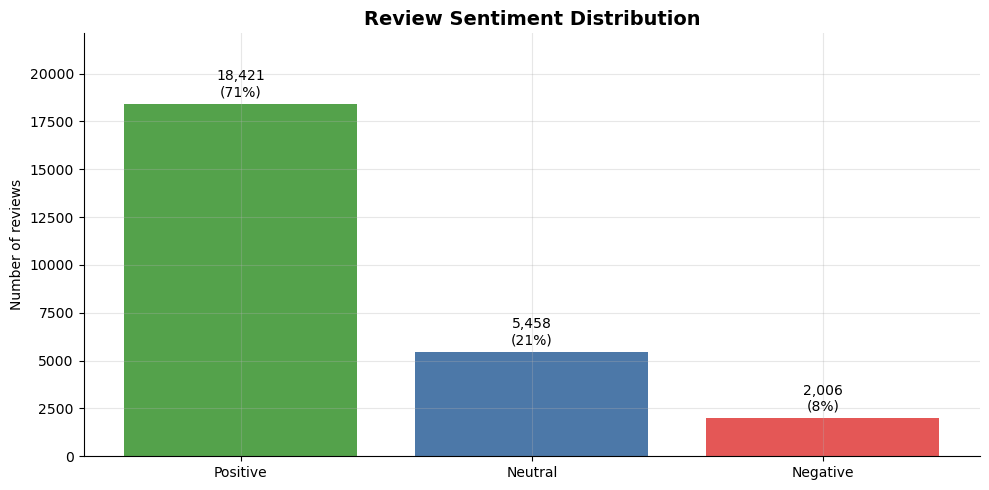

In [46]:
counts = reviews_df["sentiment"].value_counts()
colors = {"Positive": "#54A24B", "Neutral": "#4C78A8", "Negative": "#E45756"}

bars = plt.bar(counts.index, counts.values, color=[colors[s] for s in counts.index])
plt.bar_label(bars, labels=[f"{v:,}\n({v / counts.sum():.0%})" for v in counts.values], padding=3)
plt.title("Review Sentiment Distribution")
plt.ylabel("Number of reviews")
plt.ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

✅ **Outcome:** The chart clearly shows the imbalance: most reviews are Positive, so `class_weight="balanced"` is used later to stop the model from favouring the Positive class.

### Prepare the text
Each review is converted to lowercase, numbers and punctuation are removed, and extra spaces are cleaned, so "Good", "good!" and "GOOD" are treated the same.

In [47]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)    # remove numbers and punctuation
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

reviews_df["clean_text"] = reviews_df["review_text"].apply(clean_text)
reviews_df[["review_text", "clean_text", "sentiment"]].head()

,review_text,clean_text,sentiment
0,"I would buy this again, item feels durable. Re...",i would buy this again item feels durable reco...,Positive
1,"Very satisfied, seller description was accurat...",very satisfied seller description was accurate...,Positive
2,"Very satisfied, quality feels premium. Good va...",very satisfied quality feels premium good valu...,Positive
3,"Product arrived in great condition, quality fe...",product arrived in great condition quality fee...,Positive
4,"Good experience overall, packing was neat. Wil...",good experience overall packing was neat will ...,Positive


✅ **Outcome:** A new `clean_text` column is created; for example "I would buy this again, item feels durable." becomes "i would buy this again item feels durable".

### Remove duplicate review texts
Many reviews are exact copies of the same sentence. Duplicates are removed before splitting, so the same sentence cannot appear in both training and test data.

In [48]:
print("Before:", len(reviews_df))
reviews_df = reviews_df.drop_duplicates(subset="clean_text")
print("After:", len(reviews_df))

Before: 25885
After: 4484


✅ **Outcome:** Reviews dropped from 25,885 to 4,484, meaning only about 17% of reviews are unique and the rest are repeated template sentences.

### Train/test split
80% of the unique reviews are used for training and 20% for testing; `stratify` keeps the same Positive/Neutral/Negative ratio in both sets.

In [49]:
X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
    reviews_df["clean_text"], reviews_df["sentiment"],
    test_size=0.2, random_state=42, stratify=reviews_df["sentiment"])

✅ **Outcome:** 3,587 reviews are used for training and 897 for testing.

### Add short common phrases to the training set
The template reviews never use simple inputs like "bad" or "love it" on their own, so the model misclassified them. 24 short phrases (10 Negative, 8 Positive, 6 Neutral) are added 5 times each to the training set only; the test set stays unchanged.

In [50]:
extra = pd.DataFrame({
    "text": ["bad", "very bad", "bad product", "bad quality", "terrible", "horrible",
             "hate it", "waste of money", "poor", "broken",
             "good", "very good", "great", "excellent", "love it", "amazing", "nice", "perfect",
             "okay", "average", "not bad", "fine", "so so", "normal"],
    "label": ["Negative"] * 10 + ["Positive"] * 8 + ["Neutral"] * 6,
})

X_train_txt = pd.concat([X_train_txt] + [extra["text"]] * 5)
y_train_txt = pd.concat([y_train_txt] + [extra["label"]] * 5)

✅ **Outcome:** 120 extra examples are added, so the training set grows to 3,707 reviews while the test set remains 897 original reviews.

### TF-IDF + Logistic Regression
TF-IDF turns each review into numbers based on how important each word is. Single words and word pairs (`ngram_range=(1, 2)`) are used so phrases like "not good" are captured, and `class_weight="balanced"` stops the model from favouring the Positive class.

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

sentiment_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

sentiment_model.fit(X_train_txt, y_train_txt)

Pipeline(steps=[('tfidf', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

✅ **Outcome:** The sentiment model (TF-IDF + Logistic Regression) is trained inside one Pipeline, so raw text can be passed directly to it in the Streamlit app.

### Evaluate the sentiment model
Reporting Accuracy, Precision, Recall and F1-score for each sentiment class on the 897 test reviews.

In [52]:
from sklearn.metrics import classification_report

pred_txt = sentiment_model.predict(X_test_txt)

print("Accuracy:", round(accuracy_score(y_test_txt, pred_txt), 3))
print(classification_report(y_test_txt, pred_txt))

Accuracy: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       187
     Neutral       1.00      1.00      1.00       278
    Positive       1.00      1.00      1.00       432

    accuracy                           1.00       897
   macro avg       1.00      1.00      1.00       897
weighted avg       1.00      1.00      1.00       897



✅ **Outcome:** Accuracy, Precision, Recall and F1-score are all 1.00 for Negative, Neutral and Positive; this perfect score is not realistic, because the reviews are built from a small set of repeated phrases, so even unseen test sentences share the same words as the training sentences.

### Test on new sentences
Checking the model on new sentences that are not in the dataset, to see if it works on real-world input.

In [53]:
tests = ["very happy with this purchase", "worst product ever", "it is okay, average"]
for t in tests:
    print(t, "->", sentiment_model.predict([clean_text(t)])[0])

very happy with this purchase -> Positive
worst product ever -> Negative
it is okay, average -> Neutral


✅ **Outcome:** All three new sentences are classified correctly: "very happy with this purchase" → Positive, "worst product ever" → Negative and "it is okay, average" → Neutral.

### Save the sentiment model
The full Pipeline (TF-IDF + Logistic Regression) is saved with joblib so the Streamlit app can use it without retraining.

In [54]:
joblib.dump(sentiment_model, "models/sentiment_model.pkl")
print("Saved")

Saved


✅ **Outcome:** The model is saved as `models/sentiment_model.pkl` and is used in the Sentiment Analysis page of the Streamlit app.

# Conclusion

- **Data cleaning:** Missing values were filled, city and category names were standardised (13 cities, 8 categories), 13 invalid dates were fixed, and 97 invalid orders and 115 unusable reviews were removed. Orders went from 65,000 to 64,903.
- **Sales:** Total net revenue is about **PKR 865.3 million**. Electronics brings in about 70% of it, and two headphone products alone earn almost 20% of all revenue.
- **Customers and cities:** Karachi and Lahore generate about 45% of revenue, so these cities should get priority in marketing and delivery.
- **Growth and returns:** Monthly revenue grew almost 4 times in one year. Fashion has the highest return rate (11.3%), which can be reduced with better size guides and product photos.
- **Churn prediction:** About 49% of customers did not buy again in the target window. **Random Forest** was selected (Recall 0.841, ROC-AUC 0.783) because it catches the most customers who are about to leave.
- **Deep Learning:** The neural network (ROC-AUC 0.773) did not beat Random Forest, so the extra complexity was not worth it.
- **Sentiment analysis:** TF-IDF + Logistic Regression classifies reviews as Positive, Neutral or Negative, but the perfect score is unrealistic because most reviews are repeated template sentences.
- **Deployment:** The saved models are used in a Streamlit app with a SQL-based dashboard, churn prediction with retention strategies, and sentiment analysis.

In [55]:
import sklearn; print(sklearn.__version__)

1.5.1
